# EDA — 가설1: 배송 지연 경험과 이탈

> **가설**: 약속된 배송 예정일보다 실제 배송이 늦어진 고객은 이탈률이 높을 것이다.

---
## Step 1. 라이브러리 & 시각화 설정 / 데이터 로드

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=1.5)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# outputs 폴더 생성 (없으면)
os.makedirs('../outputs', exist_ok=True)

# 데이터 로드
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
reviews   = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
items     = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products  = pd.read_csv('../data/raw/olist_products_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

print("로드 완료")
print(f"  orders   : {orders.shape}")
print(f"  reviews  : {reviews.shape}")
print(f"  items    : {items.shape}")
print(f"  products : {products.shape}")
print(f"  customers: {customers.shape}")

로드 완료
  orders   : (99441, 8)
  reviews  : (99224, 7)
  items    : (112650, 7)
  products : (32951, 9)
  customers: (99441, 5)


---
## Step 2. orders 기본 확인 (레이블 생성 기반)

In [10]:
# order_status 분포 → delivered만 사용
print("=== order_status 분포 ===")
status_counts = orders['order_status'].value_counts()
print(status_counts)
delivered_ratio = status_counts.get('delivered', 0) / len(orders)
print(f"\ndelivered 비율: {delivered_ratio:.1%}")

# 전체 날짜 범위
print("\n=== 주문 날짜 범위 ===")
print(f"최소: {orders['order_purchase_timestamp'].min()}")
print(f"최대: {orders['order_purchase_timestamp'].max()}")

# 날짜 필드 결측치
print("\n=== 날짜 필드 결측치 ===")
date_cols = ['order_delivered_customer_date', 'order_estimated_delivery_date']
missing_dates = orders[date_cols].isnull().sum()
missing_pct   = orders[date_cols].isnull().mean()
for col in date_cols:
    print(f"  {col}: {missing_dates[col]:,}건 ({missing_pct[col]:.1%})")

=== order_status 분포 ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

delivered 비율: 97.0%

=== 주문 날짜 범위 ===
최소: 2016-09-04 21:15:19
최대: 2018-10-17 17:30:18

=== 날짜 필드 결측치 ===
  order_delivered_customer_date: 2,965건 (3.0%)
  order_estimated_delivery_date: 0건 (0.0%)


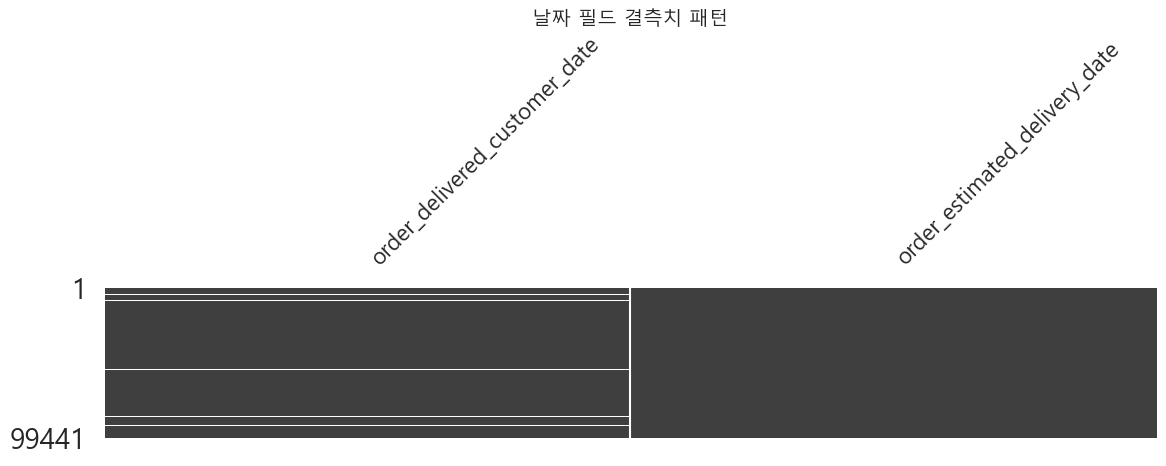

In [11]:
# 날짜 필드 결측치 시각화
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(orders[date_cols], ax=ax, sparkline=False)
ax.set_title('날짜 필드 결측치 패턴', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/eda_h1_missing_dates.png', dpi=150)
plt.show()

---
## Step 3. 클래스 불균형 사전 파악 (cutoff 기준 레이블 생성)

In [12]:
# customer_unique_id 기준으로 병합
merged = orders.merge(customers, on='customer_id')

# cutoff 설정 (이탈 정의: cutoff 이후 90일간 재구매 없음)
cutoff = orders['order_purchase_timestamp'].max() - pd.Timedelta(days=90)
print(f"cutoff 날짜: {cutoff.date()}")

# cutoff 이전 구매 고객 (피처 계산 대상)
before_cutoff = merged[merged['order_purchase_timestamp'] <= cutoff]
all_customers = set(before_cutoff['customer_unique_id'])

# cutoff 이후 구매 고객 → 유지(retained)
after_cutoff  = merged[merged['order_purchase_timestamp'] > cutoff]
retained_set  = set(after_cutoff['customer_unique_id'])

# 레이블 생성
total_customers = len(all_customers)
retained_count  = len(all_customers & retained_set)
churned_count   = total_customers - retained_count
churn_ratio     = churned_count / total_customers
retain_ratio    = retained_count / total_customers

print("\n=== 클래스 불균형 비율 ===")
print(f"  전체 고객 수  : {total_customers:,}명")
print(f"  유지(label=0) : {retained_count:,}명 ({retain_ratio:.1%})")
print(f"  이탈(label=1) : {churned_count:,}명 ({churn_ratio:.1%})")
print(f"  이탈:유지 비율 = {churned_count/max(retained_count,1):.1f}:1")

cutoff 날짜: 2018-07-19

=== 클래스 불균형 비율 ===
  전체 고객 수  : 86,924명
  유지(label=0) : 240명 (0.3%)
  이탈(label=1) : 86,684명 (99.7%)
  이탈:유지 비율 = 361.2:1


=== 구매 횟수 분포 (상위 10개) ===
order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

1회 구매 고객 비율: 96.9%


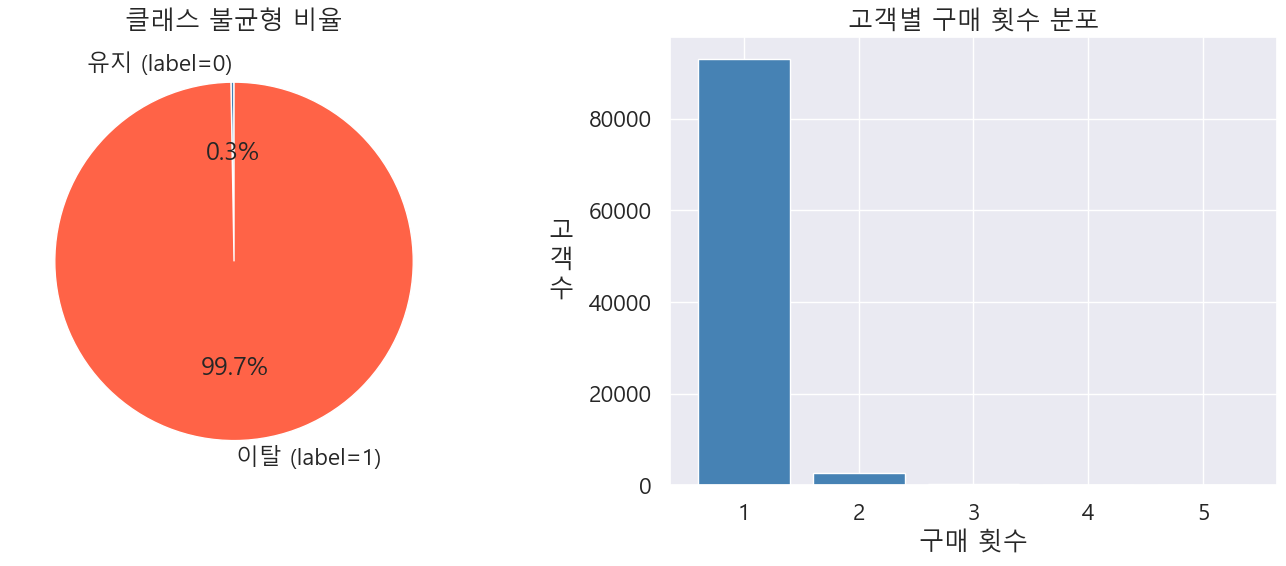

In [17]:
# 구매 횟수 분포
purchase_counts = merged.groupby('customer_unique_id')['order_id'].count()
print("=== 구매 횟수 분포 (상위 10개) ===")
print(purchase_counts.value_counts().head(10))
print(f"\n1회 구매 고객 비율: {(purchase_counts == 1).mean():.1%}")

# 클래스 불균형 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 파이 차트
axes[0].pie(
    [retain_ratio, churn_ratio],
    labels=['유지 (label=0)', '이탈 (label=1)'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[0].set_title('클래스 불균형 비율')

# 구매 횟수 분포 (1~5회)
pc_clip = purchase_counts.clip(upper=5).value_counts().sort_index()
axes[1].bar(pc_clip.index.astype(str).tolist(), pc_clip.values,
            color='steelblue', edgecolor='white')
axes[1].set_title('고객별 구매 횟수 분포')
axes[1].set_xlabel('구매 횟수')
axes[1].set_ylabel('고\n객\n수', rotation=0, labelpad=20, verticalalignment='center')

plt.tight_layout()
plt.savefig('../outputs/eda_h1_class_imbalance.png', dpi=150)
plt.show()

---
## [가설1] Step 1. delivered 주문 필터링 및 지연일 계산

In [14]:
# delivered + 날짜 결측 없는 주문만 사용
delivered = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notna()) &
    (orders['order_estimated_delivery_date'].notna())
].copy()

# 지연일 계산 (양수=지연, 음수=조기 배송)
delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

print("=== 지연일 기술 통계 ===")
print(delivered['delay_days'].describe().round(2))

# 배송 지연 비율 (필수 수치)
delay_ratio = (delivered['delay_days'] > 0).mean()
ontime_ratio = (delivered['delay_days'] <= 0).mean()

print("\n=== 배송 지연 비율 (필수 수치) ===")
print(f"  지연된 주문 비율     : {delay_ratio:.1%}")
print(f"  정시/빠른 배송 비율  : {ontime_ratio:.1%}")
print(f"  총 delivered 주문 수 : {len(delivered):,}건")

=== 지연일 기술 통계 ===
count    96470.00
mean       -11.88
std         10.18
min       -147.00
25%        -17.00
50%        -12.00
75%         -7.00
max        188.00
Name: delay_days, dtype: float64

=== 배송 지연 비율 (필수 수치) ===
  지연된 주문 비율     : 6.8%
  정시/빠른 배송 비율  : 93.2%
  총 delivered 주문 수 : 96,470건


---
## [가설1] Step 2. 지연일 분포 시각화

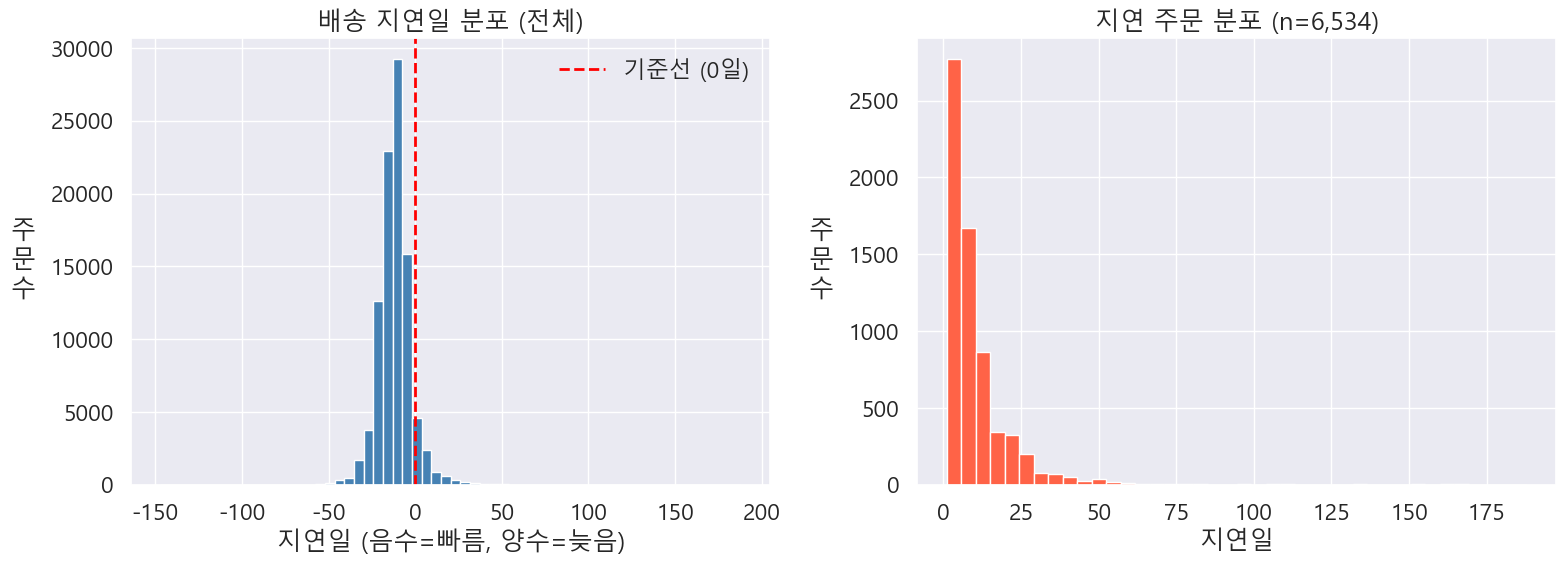

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 전체 분포
axes[0].hist(delivered['delay_days'], bins=60, edgecolor='white', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='기준선 (0일)')
axes[0].set_title('배송 지연일 분포 (전체)')
axes[0].set_xlabel('지연일 (음수=빠름, 양수=늦음)')
axes[0].set_ylabel('주\n문\n수', rotation=0, labelpad=20, verticalalignment='center')
axes[0].legend()

# 지연 주문만 확대
delayed_only = delivered[delivered['delay_days'] > 0]
axes[1].hist(delayed_only['delay_days'], bins=40, edgecolor='white', color='tomato')
axes[1].set_title(f'지연 주문 분포 (n={len(delayed_only):,})')
axes[1].set_xlabel('지연일')
axes[1].set_ylabel('주\n문\n수', rotation=0, labelpad=20, verticalalignment='center')

plt.tight_layout()
plt.savefig('../outputs/eda_h1_delay_distribution.png', dpi=150)
plt.show()

---
## [가설1] Step 3. 지연 경험 여부 × 이탈률 비교

In [24]:
# customer_unique_id 기준 병합
delivered_merged = delivered.merge(customers, on='customer_id')

# 고객별: 지연 경험 여부, 주문 수
customer_delay = delivered_merged.groupby('customer_unique_id').agg(
    ever_delayed=('delay_days', lambda x: (x > 0).any()),
    order_count =('order_id', 'nunique')
).reset_index()

# cutoff 기준 재구매 여부 (레이블) — Step 4에서 정의한 retained_set 재사용
cutoff = orders['order_purchase_timestamp'].max() - pd.Timedelta(days=90)
after  = orders.merge(customers, on='customer_id')
after  = after[after['order_purchase_timestamp'] > cutoff]
retained = set(after['customer_unique_id'])

customer_delay['retained'] = customer_delay['customer_unique_id'].isin(retained).astype(int)
customer_delay['churned']  = 1 - customer_delay['retained']

# 그룹별 이탈률
churn_by_delay = customer_delay.groupby('ever_delayed')['churned'].mean()
print("=== 지연 경험 여부별 이탈률 ===")
print(f"  지연 경험 없음 이탈률: {churn_by_delay[False]:.1%}")
print(f"  지연 경험 있음 이탈률: {churn_by_delay[True]:.1%}")
diff = churn_by_delay[True] - churn_by_delay[False]
print(f"  차이 (있음 - 없음)   : {diff:+.1%}")
print(f"  → 가설 유효성 판단 기준: 5%p 이상 차이")

=== 지연 경험 여부별 이탈률 ===
  지연 경험 없음 이탈률: 90.0%
  지연 경험 있음 이탈률: 92.1%
  차이 (있음 - 없음)   : +2.1%
  → 가설 유효성 판단 기준: 5%p 이상 차이


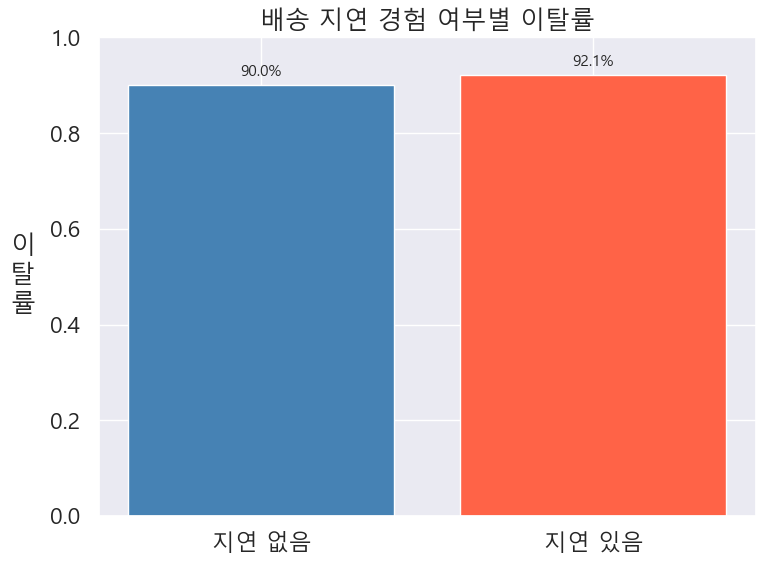

In [36]:
# 시각화
plot_data = churn_by_delay.rename({False: '지연 없음', True: '지연 있음'})

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(plot_data.index, plot_data.values,
               color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('배송 지연 경험 여부별 이탈률')
ax.set_ylabel('이\n탈\n률', rotation=0, labelpad=20, verticalalignment='center')
ax.set_ylim(0, 1)

# 수치 레이블
for bar, val in zip(bars, plot_data.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/eda_h1_churn_by_delay.png', dpi=150)
plt.show()

---
## [가설1] Step 4. 지연 정도(구간)별 이탈률

In [26]:
# 지연 구간 분류
bins   = [-999, 0, 3, 7, 14, 999]
labels = ['빠름', '0~3일', '3~7일', '7~14일', '14일 초과']

delivered_merged2 = delivered.merge(customers, on='customer_id').copy()
delivered_merged2['delay_group'] = pd.cut(
    delivered_merged2['delay_days'], bins=bins, labels=labels
)

# 고객별 최빈 지연 구간
cust_delay_group = delivered_merged2.groupby('customer_unique_id').agg(
    delay_group=('delay_group', lambda x: x.mode()[0])
).reset_index()
cust_delay_group['churned'] = (
    ~cust_delay_group['customer_unique_id'].isin(retained)
).astype(int)

# 구간별 이탈률
churn_by_group = cust_delay_group.groupby('delay_group', observed=True)['churned'].mean()
count_by_group = cust_delay_group.groupby('delay_group', observed=True)['churned'].count()

print("=== 지연 구간별 이탈률 ===")
for grp in labels:
    if grp in churn_by_group.index:
        print(f"  {grp:10s}: {churn_by_group[grp]:.1%}  (n={count_by_group[grp]:,})")

=== 지연 구간별 이탈률 ===
  빠름        : 90.0%  (n=87,124)
  0~3일      : 86.0%  (n=1,788)
  3~7일      : 91.1%  (n=1,714)
  7~14일     : 96.0%  (n=1,408)
  14일 초과    : 98.1%  (n=1,316)


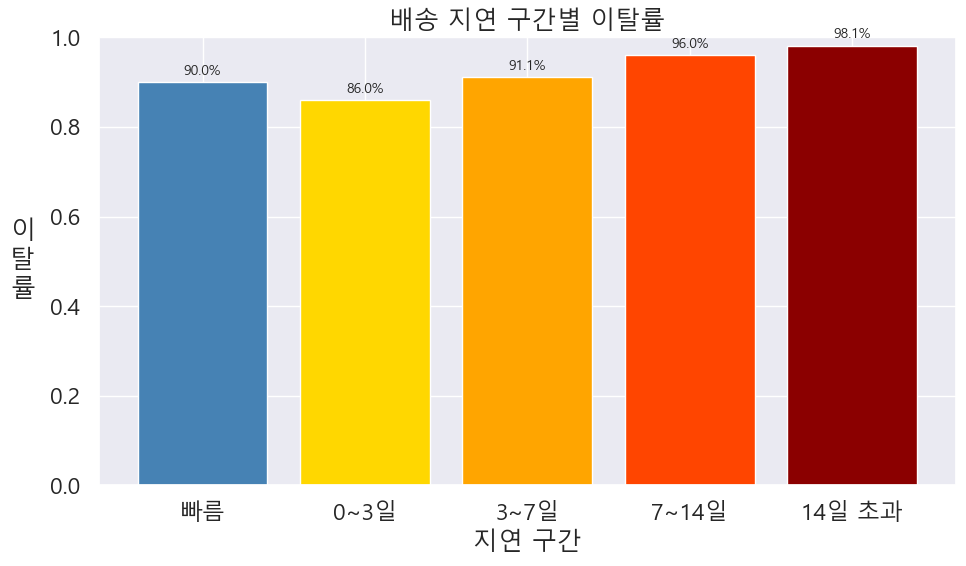

In [29]:
# 구간별 이탈률 시각화
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    churn_by_group.index.astype(str),
    churn_by_group.values,
    color=['steelblue', 'gold', 'orange', 'orangered', 'darkred'],
    edgecolor='white'
)
ax.set_title('배송 지연 구간별 이탈률')
ax.set_ylabel('이\n탈\n률', rotation=0, labelpad=20, verticalalignment='center')
ax.set_xlabel('지연 구간')
ax.set_ylim(0, 1)

for bar, val in zip(bars, churn_by_group.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/eda_h1_churn_by_delay_group.png', dpi=150)
plt.show()

---
## 체크 포인트 & 결론 정리

In [32]:
print("=" * 50)
print("EDA 가설1 요약")
print("=" * 50)

print(f"\n[클래스 불균형]")
print(f"  이탈 비율 (label=1) : {churn_ratio:.1%}")
print(f"  유지 비율 (label=0) : {retain_ratio:.1%}")

print(f"\n[배송 지연 비율]")
print(f"  지연 주문 비율 : {delay_ratio:.1%}")

print(f"\n[가설1 결론]")
diff_abs = abs(churn_by_delay[True] - churn_by_delay[False])
is_valid = diff_abs >= 0.05
print(f"  지연 없음 이탈률: {churn_by_delay[False]:.1%}")
print(f"  지연 있음 이탈률: {churn_by_delay[True]:.1%}")
print(f"  이탈률 차이    : {diff_abs:.1%}")

EDA 가설1 요약

[클래스 불균형]
  이탈 비율 (label=1) : 99.7%
  유지 비율 (label=0) : 0.3%

[배송 지연 비율]
  지연 주문 비율 : 6.8%

[가설1 결론]
  지연 없음 이탈률: 90.0%
  지연 있음 이탈률: 92.1%
  이탈률 차이    : 2.1%
